### Importing the libraries  

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Retrieve the dataset

In [146]:
df = pd.read_csv("./data/ad_click_prediction_train.csv")
df_test = pd.read_csv("./data/ad_click_prediction_test.csv")
df.head()

,session_id,DateTime,user_id,product,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,gender,age_level,user_depth,city_development_index,var_1,is_click
0,140690,2017-07-02 00:00,858557,C,359520,13787,4,NaN,10.0,Female,4.0,3.0,3.0,0,0
1,333291,2017-07-02 00:00,243253,C,105960,11085,5,NaN,8.0,Female,2.0,2.0,NaN,0,0
2,129781,2017-07-02 00:00,243253,C,359520,13787,4,NaN,8.0,Female,2.0,2.0,NaN,0,0
3,464848,2017-07-02 00:00,1097446,I,359520,13787,3,NaN,3.0,Male,3.0,3.0,2.0,1,0
4,90569,2017-07-02 00:01,663656,C,405490,60305,3,NaN,2.0,Male,2.0,3.0,2.0,1,0


1. Data Preparation & Feature Engineering: Quality of data cleaning, imputation, handling of categorical data, and the predictive power of engineered features (behavioral, temporal, contextual).

In [147]:
df.shape

(463291, 15)

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   session_id              463291 non-null  int64  
 1   DateTime                463291 non-null  object 
 2   user_id                 463291 non-null  int64  
 3   product                 463291 non-null  object 
 4   campaign_id             463291 non-null  int64  
 5   webpage_id              463291 non-null  int64  
 6   product_category_1      463291 non-null  int64  
 7   product_category_2      97437 non-null   float64
 8   user_group_id           445048 non-null  float64
 9   gender                  445048 non-null  object 
 10  age_level               445048 non-null  float64
 11  user_depth              445048 non-null  float64
 12  city_development_index  338162 non-null  float64
 13  var_1                   463291 non-null  int64  
 14  is_click            

In [149]:
df.nunique()

session_id                463291
DateTime                    8610
user_id                   150347
product                       10
campaign_id                   10
webpage_id                     9
product_category_1             5
product_category_2            29
user_group_id                 13
gender                         2
age_level                      7
user_depth                     3
city_development_index         4
var_1                          2
is_click                       2
dtype: int64

In [150]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
identifier = ['session_id', 'user_id']
categorical = ['product', 'campaign_id', 'webpage_id', 'product_category_1', 'product_category_2', 'user_group_id', 'gender', 'user_depth', 'city_development_index', 'var_1', 'is_click']
categorical_ordinal = ['age_level']
temporal = ['DateTime']
numerical = []

In [151]:
ctr = df['is_click'].mean()
print(f"CTR: {ctr:.4%}")

CTR: 6.7627%


In [152]:
df.isnull().sum()

session_id                     0
DateTime                       0
user_id                        0
product                        0
campaign_id                    0
webpage_id                     0
product_category_1             0
product_category_2        365854
user_group_id              18243
gender                     18243
age_level                  18243
user_depth                 18243
city_development_index    125129
var_1                          0
is_click                       0
dtype: int64

## 1. Target Distribution & Imbalance Analysis
- What percentage of ads get clicked?
- Is the dataset severely imbalanced?
- Do you need resampling techniques?

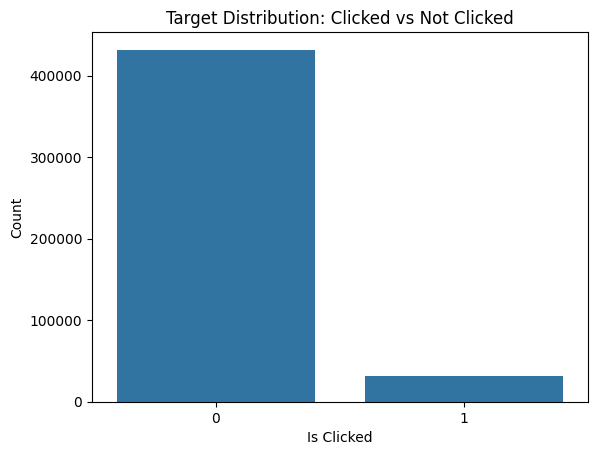

Clicked: 31331 (6.76%)
Not Clicked: 431960 (93.24%)
The dataset is imbalanced. Consider resampling techniques.


In [153]:
# Plot target distribution
import matplotlib.pyplot as plt
sns.countplot(x='is_click', data=df)
plt.title('Target Distribution: Clicked vs Not Clicked')
plt.xlabel('Is Clicked')
plt.ylabel('Count')
plt.show()

# Calculate class balance
clicked = df['is_click'].sum()
total = len(df)
not_clicked = total - clicked
print(f"Clicked: {clicked} ({clicked/total:.2%})\nNot Clicked: {not_clicked} ({not_clicked/total:.2%})")

# Imbalance check
imbalance_ratio = clicked / total
if imbalance_ratio < 0.2 or imbalance_ratio > 0.8:
    print('The dataset is imbalanced. Consider resampling techniques.')
else:
    print('The dataset is reasonably balanced.')

## 2. Temporal Patterns in Click Rates
- Which hours have highest click rates?
- Are weekends different from weekdays?
- Do certain months perform better?

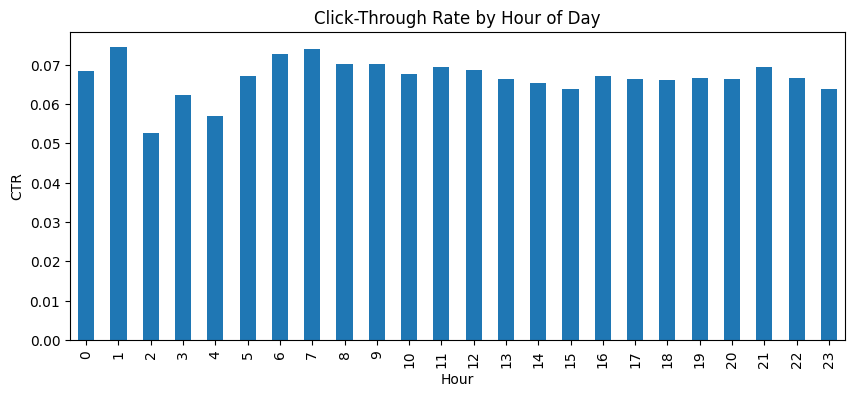

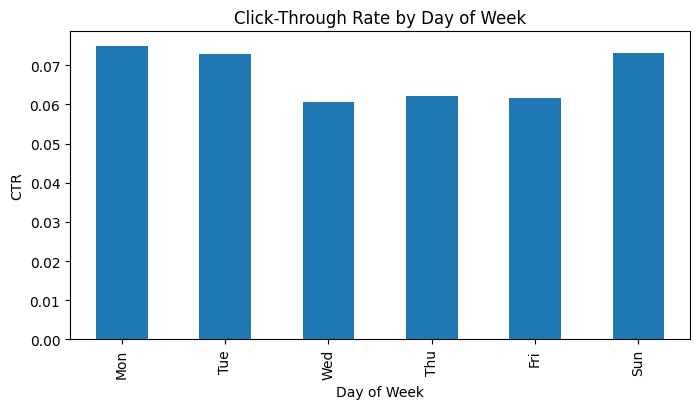

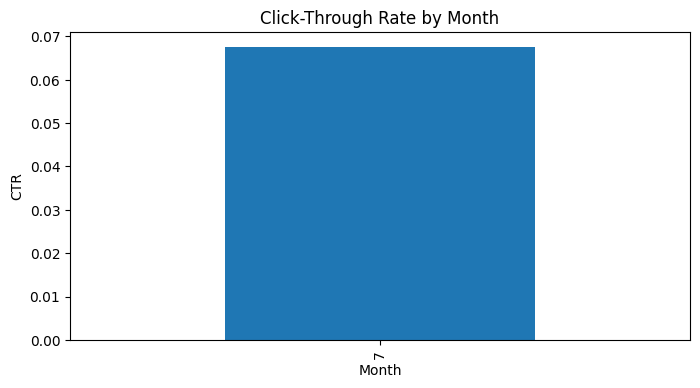

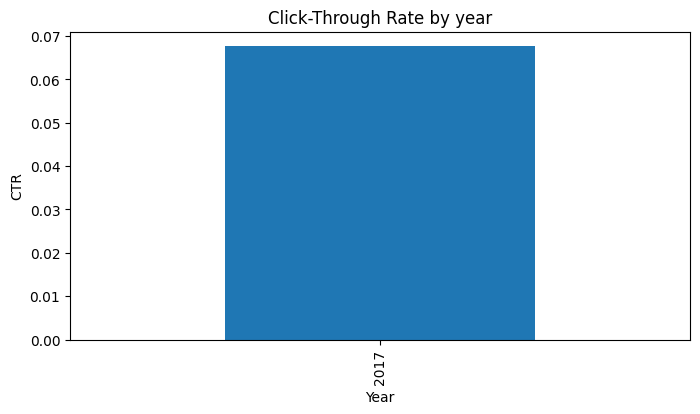

In [164]:
# Extract temporal features
# Hour of day
if 'hour' not in df.columns:
    df['hour'] = df['DateTime'].dt.hour
# Day of week
if 'weekday' not in df.columns:
    df['weekday'] = df['DateTime'].dt.dayofweek
# Month
if 'month' not in df.columns:
    df['month'] = df['DateTime'].dt.month

if 'year' not in df.columns:
    df['year'] = df['DateTime'].dt.year

# Click rate by hour
hourly_ctr = df.groupby('hour')['is_click'].mean()
hourly_ctr.plot(kind='bar', figsize=(10,4))
plt.title('Click-Through Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('CTR')
plt.show()

# Click rate by weekday
weekday_ctr = df.groupby('weekday')['is_click'].mean()
weekday_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
weekday_ctr.index = [weekday_names[i] for i in weekday_ctr.index]
weekday_ctr.plot(kind='bar', figsize=(8,4))
plt.title('Click-Through Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('CTR')
plt.show()

# Click rate by month
monthly_ctr = df.groupby('month')['is_click'].mean()
monthly_ctr.plot(kind='bar', figsize=(8,4))
plt.title('Click-Through Rate by Month')
plt.xlabel('Month')
plt.ylabel('CTR')
plt.show()

# Click rate by year
monthly_ctr = df.groupby('year')['is_click'].mean()
monthly_ctr.plot(kind='bar', figsize=(8,4))
plt.title('Click-Through Rate by year')
plt.xlabel('Year')
plt.ylabel('CTR')
plt.show()

> Data is present for the month of july 2017

In [165]:
print("Unique weekdays in dataset:")
print(df['weekday'].unique())
print("\nWeekday value counts:")
print(df['weekday'].value_counts().sort_index())

Unique weekdays in dataset:
[6 0 1 2 3 4]

Weekday value counts:
weekday
0    81380
1    73085
2    80789
3    77526
4    71466
6    79045
Name: count, dtype: int64


In [166]:
df_test['DateTime'] = pd.to_datetime(df_test['DateTime'])
if 'hour' not in df_test.columns:
    df_test['hour'] = df_test['DateTime'].dt.hour
# Day of week
if 'weekday' not in df_test.columns:
    df_test['weekday'] = df_test['DateTime'].dt.dayofweek
# Month
if 'month' not in df_test.columns:
    df_test['month'] = df_test['DateTime'].dt.month

print("Unique weekdays in dataset:")
print(df_test['weekday'].unique())
print("\nWeekday value counts:")
print(df_test['weekday'].value_counts().sort_index())

Unique weekdays in dataset:
[5 6]

Weekday value counts:
weekday
5    66874
6    61984
Name: count, dtype: int64


In [167]:
# Check if test set has target variable
print("Test dataset columns:")
print(df_test.columns.tolist())
print(f"\nTest dataset shape: {df_test.shape}")
print(f"Has 'is_click' column: {'is_click' in df_test.columns}")

Test dataset columns:
['session_id', 'DateTime', 'user_id', 'product', 'campaign_id', 'webpage_id', 'product_category_1', 'product_category_2', 'user_group_id', 'gender', 'age_level', 'user_depth', 'city_development_index', 'var_1', 'hour', 'weekday', 'month']

Test dataset shape: (128858, 17)
Has 'is_click' column: False


> **Finding:** Cannot Merge Test dataset does NOT have the `is_click` target variable.

In [168]:
print("Top 5 hours with highest CTR")
print(hourly_ctr.sort_values(ascending=False).head(5))

print("Bottom 5 hours with lowest CTR")
print(hourly_ctr.sort_values().head(5))

Top 5 hours with highest CTR
hour
1    0.074608
7    0.073978
6    0.072822
8    0.070271
9    0.070101
Name: is_click, dtype: float64
Bottom 5 hours with lowest CTR
hour
2     0.052732
4     0.057005
3     0.062237
23    0.063736
15    0.063929
Name: is_click, dtype: float64


> Which hours have highest click rates?

> Data shows that Best hours for highest CTR are 1, 7, 6, 8, 9

> Are weekends different from weekdays?

In [169]:
weekday_ctr

Mon    0.074932
Tue    0.072888
Wed    0.060689
Thu    0.062057
Fri    0.061582
Sun    0.073262
Name: is_click, dtype: float64

In [181]:
weekdays_ctr = weekday_ctr.drop(columns=['Sun']).mean()

print(f"Weekdays CTR {weekdays_ctr}")
print(f"Weekend CTR {weekday_ctr['Sun']}")
diff_in_per = ((weekday_ctr['Sun'] - weekdays_ctr) / weekdays_ctr)
print(f"{diff_in_per:.4%}")

Weekdays CTR 0.06756825031976356
Weekend CTR 0.07326206591182238
8.4268%
